In [1]:
import gc
gc.collect()

42

In [2]:
import os
import random
from tqdm import tqdm


import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt
import plotly.express as px

import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader,random_split
from torch import nn
import torch.nn.functional as F
import torch.optim as optim

In [4]:
# loading data

data_dir = '../data'

train_dataset = torchvision.datasets.FashionMNIST(data_dir, train=True, download=True)
test_dataset  = torchvision.datasets.FashionMNIST(data_dir, train=False, download=True)

print(train_dataset)
type(train_dataset)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train


torchvision.datasets.mnist.FashionMNIST

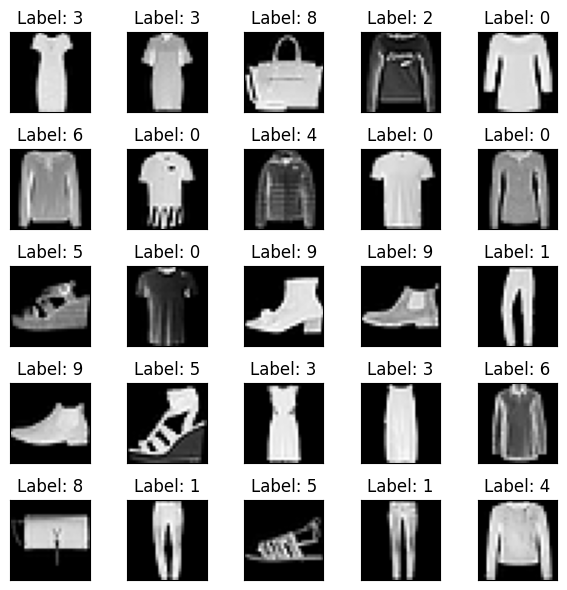

In [5]:
# display images examples

fig, axs = plt.subplots(5, 5, figsize=(6,6))
for ax in axs.flatten():
    img, label = random.choice(train_dataset)
    ax.imshow(np.array(img), cmap='gist_gray')
    ax.set_title('Label: %d' % label)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

In [6]:
# data to tensors

train_transform = transforms.Compose([
    transforms.ToTensor(),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
])

# Set the train transform
train_dataset.transform = train_transform
# Set the test transform
test_dataset.transform = test_transform

In [7]:
# adding validation split

m=len(train_dataset)

train_data, val_data = random_split(train_dataset, [int(len(train_dataset)*0.8), int(m*0.2)])

batch_size=256

# The dataloaders handle shuffling, batching, etc...
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size)
valid_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,shuffle=True)

In [8]:
class Encoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim):
        super().__init__()
        
        # Convolutional section
        self.encoder_cnn = nn.Sequential(
            # First convolutional layer
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            #nn.BatchNorm2d(8),
            nn.ReLU(True),
            # Second convolutional layer
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            # Third convolutional layer
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            #nn.BatchNorm2d(32),
            nn.ReLU(True)
        )
        
        # Flatten layer
        self.flatten = nn.Flatten(start_dim=1)

        # Linear section
        self.encoder_lin = nn.Sequential(
            # First linear layer
            nn.Linear(3 * 3 * 32, 128),
            nn.ReLU(True),
            # Second linear layer
            nn.Linear(128, encoded_space_dim)
        )
        
    def forward(self, x):
        # Apply convolutions
        x = self.encoder_cnn(x)
        # Flatten
        x = self.flatten(x)
        # # Apply linear layers
        x = self.encoder_lin(x)
        return x

In [9]:
class Decoder(nn.Module):
    
    def __init__(self, encoded_space_dim,fc2_input_dim=128):
        super().__init__()

        # Linear section
        self.decoder_lin = nn.Sequential(
            # First linear layer
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            # Second linear layer
            nn.Linear(128, 3 * 3 * 32),
            nn.ReLU(True)
        )

        # Unflatten
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(32, 3, 3))

        # Convolutional section
        self.decoder_conv = nn.Sequential(
            # First transposed convolution
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            # Second transposed convolution
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            # Third transposed convolution
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1)
        )
        
    def forward(self, x):
        # Apply linear layers
        x = self.decoder_lin(x)
        # Unflatten
        x = self.unflatten(x)
        # Apply transposed convolutions
        x = self.decoder_conv(x)
        # Apply a sigmoid to force the output to be between 0 and 1 (valid pixel values)
        x = torch.sigmoid(x)
        return x

In [10]:
# Set the random seed for reproducible results
torch.manual_seed(42)

# Initialize the two networks
dim = 4

encoder = Encoder(encoded_space_dim=dim, fc2_input_dim=128)
decoder = Decoder(encoded_space_dim=dim, fc2_input_dim=128)

In [11]:
# Example on the untrained model

img, _ = test_dataset[0]
img = img.unsqueeze(0) # Add the batch dimension in the first axis
print('Original image shape:', img.shape)

# Encode the image
img_enc = encoder(img)
print('Encoded image shape:', img_enc.shape)

# Decode the image
dec_img = decoder(img_enc)
print('Decoded image shape:', dec_img.shape)

Original image shape: torch.Size([1, 1, 28, 28])
Encoded image shape: torch.Size([1, 4])
Decoded image shape: torch.Size([1, 1, 28, 28])


In [12]:
# Define the loss function
loss_fn = torch.nn.MSELoss()

# Define an optimizer (both for the encoder and the decoder!)
lr= 0.001

params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]

optim = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)

# Check if the GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Selected device: {device}')

# Move both the encoder and the decoder to the selected device
encoder.to(device)

Selected device: cpu


Encoder(
  (encoder_cnn): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2))
    (6): ReLU(inplace=True)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (encoder_lin): Sequential(
    (0): Linear(in_features=288, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [13]:
decoder.to(device)

Decoder(
  (decoder_lin): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=288, bias=True)
    (3): ReLU(inplace=True)
  )
  (unflatten): Unflatten(dim=1, unflattened_size=(32, 3, 3))
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(8, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  )
)

In [14]:
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer):
    # Set train mode for both the encoder and the decoder
    encoder.train()
    decoder.train()
    train_loss = []
    # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
    for image_batch, _ in dataloader: # with "_" we just ignore the labels (the second element of the dataloader tuple)
        # Move tensor to the proper device
        image_batch = image_batch.to(device)
        # Encode data
        encoded_data = encoder(image_batch)
        # Decode data
        decoded_data = decoder(encoded_data)
        # Evaluate loss
        loss = loss_fn(decoded_data, image_batch)
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Print batch loss
        print('\t partial train loss (single batch): %f' % (loss.data))
        train_loss.append(loss.detach().cpu().numpy())

    return np.mean(train_loss)

In [15]:
def test_epoch(encoder, decoder, device, dataloader, loss_fn):
    # Set evaluation mode for encoder and decoder
    encoder.eval()
    decoder.eval()
    with torch.no_grad(): # No need to track the gradients
        # Define the lists to store the outputs for each batch
        conc_out = []
        conc_label = []
        for image_batch, _ in dataloader:
            # Move tensor to the proper device
            image_batch = image_batch.to(device)
            # Encode data
            encoded_data = encoder(image_batch)
            # Decode data
            decoded_data = decoder(encoded_data)
            # Append the network output and the original image to the lists
            conc_out.append(decoded_data.cpu())
            conc_label.append(image_batch.cpu())
        # Create a single tensor with all the values in the lists
        conc_out = torch.cat(conc_out)
        conc_label = torch.cat(conc_label) 
        # Evaluate global loss
        val_loss = loss_fn(conc_out, conc_label)
    return val_loss.data

In [16]:
def plot_ae_outputs(encoder,decoder,n=5):
    plt.figure(figsize=(10,4.5))
    for i in range(n):
        ax = plt.subplot(2,n,i+1)
        img = test_dataset[i][0].unsqueeze(0).to(device)
        encoder.eval()
        decoder.eval()
        with torch.no_grad():
            rec_img  = decoder(encoder(img))
        plt.imshow(img.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)  
        if i == n//2:
            ax.set_title('Original images')
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')  
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)  
        if i == n//2:
            ax.set_title('Reconstructed images')
    plt.show()

	 partial train loss (single batch): 0.251189
	 partial train loss (single batch): 0.237749
	 partial train loss (single batch): 0.229475
	 partial train loss (single batch): 0.230619
	 partial train loss (single batch): 0.224111
	 partial train loss (single batch): 0.223054
	 partial train loss (single batch): 0.217117
	 partial train loss (single batch): 0.211984
	 partial train loss (single batch): 0.212013
	 partial train loss (single batch): 0.206544
	 partial train loss (single batch): 0.204550
	 partial train loss (single batch): 0.203662
	 partial train loss (single batch): 0.195886
	 partial train loss (single batch): 0.201863
	 partial train loss (single batch): 0.195048
	 partial train loss (single batch): 0.189444
	 partial train loss (single batch): 0.192628
	 partial train loss (single batch): 0.190407
	 partial train loss (single batch): 0.186354
	 partial train loss (single batch): 0.186149
	 partial train loss (single batch): 0.179732
	 partial train loss (single batch

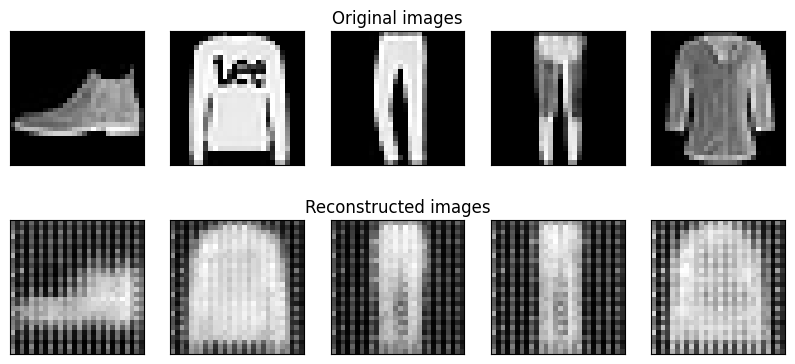

	 partial train loss (single batch): 0.057608
	 partial train loss (single batch): 0.055110
	 partial train loss (single batch): 0.053807
	 partial train loss (single batch): 0.055395
	 partial train loss (single batch): 0.054679
	 partial train loss (single batch): 0.055581
	 partial train loss (single batch): 0.054184
	 partial train loss (single batch): 0.053570
	 partial train loss (single batch): 0.053157
	 partial train loss (single batch): 0.053435
	 partial train loss (single batch): 0.053015
	 partial train loss (single batch): 0.052165
	 partial train loss (single batch): 0.049692
	 partial train loss (single batch): 0.052771
	 partial train loss (single batch): 0.050797
	 partial train loss (single batch): 0.049875
	 partial train loss (single batch): 0.051175
	 partial train loss (single batch): 0.051358
	 partial train loss (single batch): 0.050432
	 partial train loss (single batch): 0.050190
	 partial train loss (single batch): 0.048035
	 partial train loss (single batch

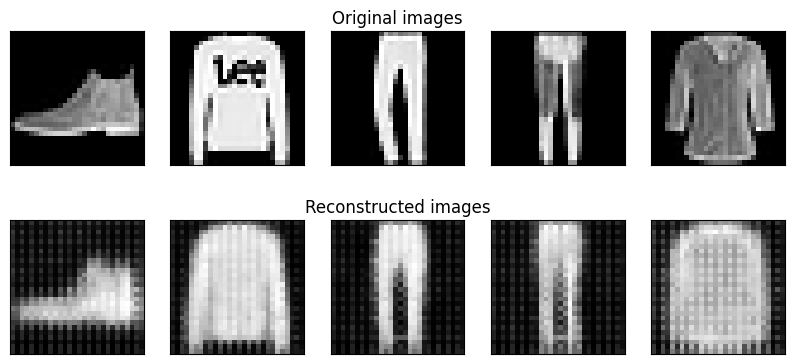

	 partial train loss (single batch): 0.031558
	 partial train loss (single batch): 0.030587
	 partial train loss (single batch): 0.029049
	 partial train loss (single batch): 0.029726
	 partial train loss (single batch): 0.029989
	 partial train loss (single batch): 0.030794
	 partial train loss (single batch): 0.030026
	 partial train loss (single batch): 0.030496
	 partial train loss (single batch): 0.029884
	 partial train loss (single batch): 0.030510
	 partial train loss (single batch): 0.030470
	 partial train loss (single batch): 0.029124
	 partial train loss (single batch): 0.028078
	 partial train loss (single batch): 0.029553
	 partial train loss (single batch): 0.029000
	 partial train loss (single batch): 0.029435
	 partial train loss (single batch): 0.028733
	 partial train loss (single batch): 0.030095
	 partial train loss (single batch): 0.029490
	 partial train loss (single batch): 0.029463
	 partial train loss (single batch): 0.027954
	 partial train loss (single batch

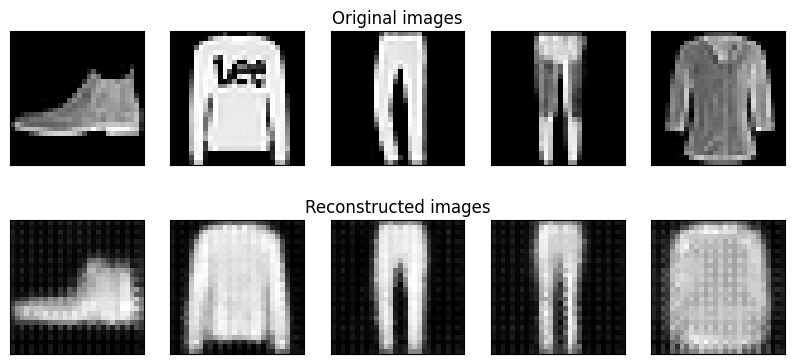

	 partial train loss (single batch): 0.026313
	 partial train loss (single batch): 0.025591
	 partial train loss (single batch): 0.023982
	 partial train loss (single batch): 0.024290
	 partial train loss (single batch): 0.025096
	 partial train loss (single batch): 0.025503
	 partial train loss (single batch): 0.024933
	 partial train loss (single batch): 0.025947
	 partial train loss (single batch): 0.024940
	 partial train loss (single batch): 0.025563
	 partial train loss (single batch): 0.025584
	 partial train loss (single batch): 0.024162
	 partial train loss (single batch): 0.023304
	 partial train loss (single batch): 0.024247
	 partial train loss (single batch): 0.024295
	 partial train loss (single batch): 0.024623
	 partial train loss (single batch): 0.023835
	 partial train loss (single batch): 0.025247
	 partial train loss (single batch): 0.024917
	 partial train loss (single batch): 0.024782
	 partial train loss (single batch): 0.023351
	 partial train loss (single batch

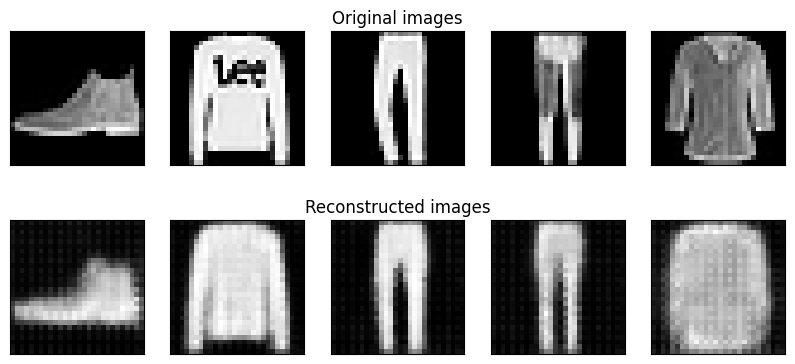

	 partial train loss (single batch): 0.024163
	 partial train loss (single batch): 0.023607
	 partial train loss (single batch): 0.022003
	 partial train loss (single batch): 0.022141
	 partial train loss (single batch): 0.023142
	 partial train loss (single batch): 0.023331
	 partial train loss (single batch): 0.022871
	 partial train loss (single batch): 0.024196
	 partial train loss (single batch): 0.023022
	 partial train loss (single batch): 0.023689
	 partial train loss (single batch): 0.023639
	 partial train loss (single batch): 0.022189
	 partial train loss (single batch): 0.021425
	 partial train loss (single batch): 0.022172
	 partial train loss (single batch): 0.022461
	 partial train loss (single batch): 0.022809
	 partial train loss (single batch): 0.021899
	 partial train loss (single batch): 0.023342
	 partial train loss (single batch): 0.023040
	 partial train loss (single batch): 0.022881
	 partial train loss (single batch): 0.021568
	 partial train loss (single batch

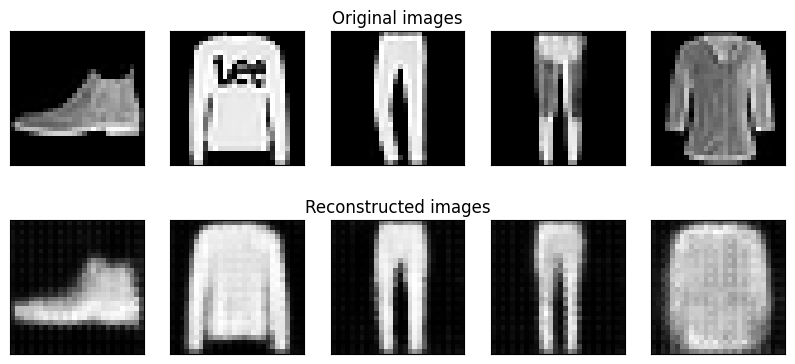

	 partial train loss (single batch): 0.023046
	 partial train loss (single batch): 0.022611
	 partial train loss (single batch): 0.021055
	 partial train loss (single batch): 0.021079
	 partial train loss (single batch): 0.022144
	 partial train loss (single batch): 0.022295
	 partial train loss (single batch): 0.021818
	 partial train loss (single batch): 0.023275
	 partial train loss (single batch): 0.022064
	 partial train loss (single batch): 0.022782
	 partial train loss (single batch): 0.022660
	 partial train loss (single batch): 0.021140
	 partial train loss (single batch): 0.020491
	 partial train loss (single batch): 0.021194
	 partial train loss (single batch): 0.021596
	 partial train loss (single batch): 0.021834
	 partial train loss (single batch): 0.020923
	 partial train loss (single batch): 0.022329
	 partial train loss (single batch): 0.022034
	 partial train loss (single batch): 0.021931
	 partial train loss (single batch): 0.020616
	 partial train loss (single batch

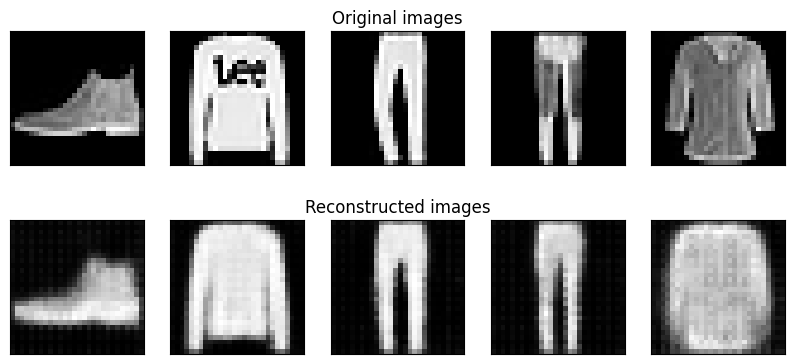

	 partial train loss (single batch): 0.022420
	 partial train loss (single batch): 0.021989
	 partial train loss (single batch): 0.020529
	 partial train loss (single batch): 0.020462
	 partial train loss (single batch): 0.021604
	 partial train loss (single batch): 0.021652
	 partial train loss (single batch): 0.021149
	 partial train loss (single batch): 0.022759
	 partial train loss (single batch): 0.021467
	 partial train loss (single batch): 0.022150
	 partial train loss (single batch): 0.022086
	 partial train loss (single batch): 0.020541
	 partial train loss (single batch): 0.019975
	 partial train loss (single batch): 0.020579
	 partial train loss (single batch): 0.021038
	 partial train loss (single batch): 0.021262
	 partial train loss (single batch): 0.020323
	 partial train loss (single batch): 0.021834
	 partial train loss (single batch): 0.021453
	 partial train loss (single batch): 0.021439
	 partial train loss (single batch): 0.020010
	 partial train loss (single batch

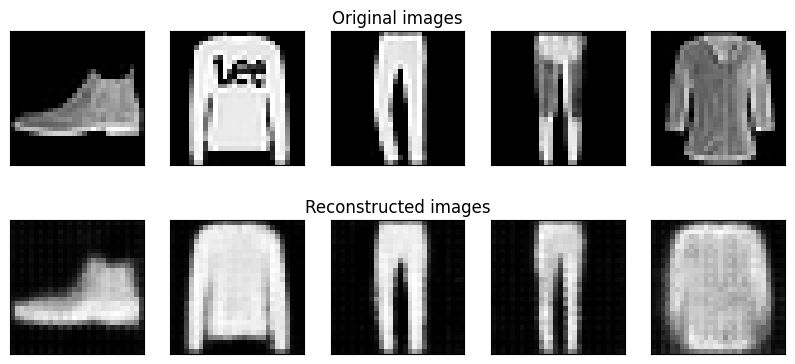

	 partial train loss (single batch): 0.022008
	 partial train loss (single batch): 0.021547
	 partial train loss (single batch): 0.020105
	 partial train loss (single batch): 0.019993
	 partial train loss (single batch): 0.021242
	 partial train loss (single batch): 0.021209
	 partial train loss (single batch): 0.020716
	 partial train loss (single batch): 0.022362
	 partial train loss (single batch): 0.021086
	 partial train loss (single batch): 0.021684
	 partial train loss (single batch): 0.021683
	 partial train loss (single batch): 0.020106
	 partial train loss (single batch): 0.019587
	 partial train loss (single batch): 0.020247
	 partial train loss (single batch): 0.020602
	 partial train loss (single batch): 0.020923
	 partial train loss (single batch): 0.019882
	 partial train loss (single batch): 0.021437
	 partial train loss (single batch): 0.021021
	 partial train loss (single batch): 0.021042
	 partial train loss (single batch): 0.019551
	 partial train loss (single batch

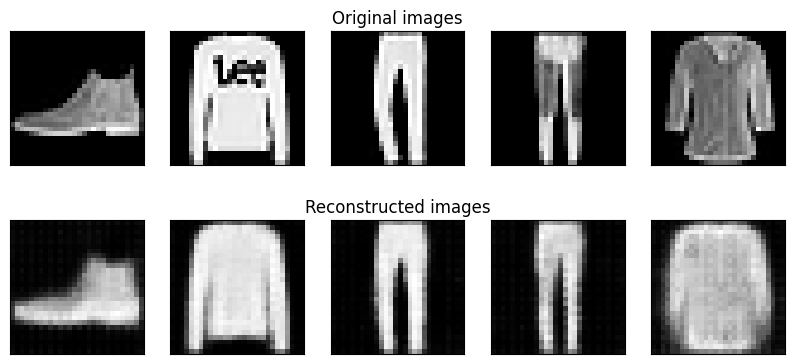

	 partial train loss (single batch): 0.021623
	 partial train loss (single batch): 0.021234
	 partial train loss (single batch): 0.019805
	 partial train loss (single batch): 0.019679
	 partial train loss (single batch): 0.020946
	 partial train loss (single batch): 0.020858
	 partial train loss (single batch): 0.020359
	 partial train loss (single batch): 0.022060
	 partial train loss (single batch): 0.020805
	 partial train loss (single batch): 0.021362
	 partial train loss (single batch): 0.021347
	 partial train loss (single batch): 0.019760
	 partial train loss (single batch): 0.019319
	 partial train loss (single batch): 0.019952
	 partial train loss (single batch): 0.020260
	 partial train loss (single batch): 0.020616
	 partial train loss (single batch): 0.019538
	 partial train loss (single batch): 0.021187
	 partial train loss (single batch): 0.020715
	 partial train loss (single batch): 0.020749
	 partial train loss (single batch): 0.019225
	 partial train loss (single batch

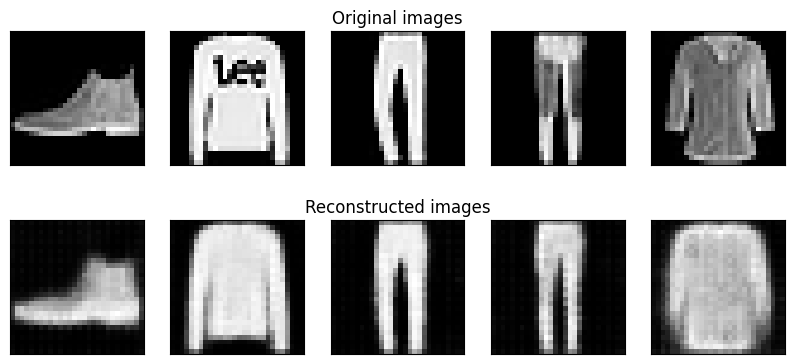

	 partial train loss (single batch): 0.021262
	 partial train loss (single batch): 0.021011
	 partial train loss (single batch): 0.019589
	 partial train loss (single batch): 0.019420
	 partial train loss (single batch): 0.020748
	 partial train loss (single batch): 0.020600
	 partial train loss (single batch): 0.020136
	 partial train loss (single batch): 0.021845
	 partial train loss (single batch): 0.020537
	 partial train loss (single batch): 0.021148
	 partial train loss (single batch): 0.021050
	 partial train loss (single batch): 0.019540
	 partial train loss (single batch): 0.019129
	 partial train loss (single batch): 0.019694
	 partial train loss (single batch): 0.020059
	 partial train loss (single batch): 0.020379
	 partial train loss (single batch): 0.019339
	 partial train loss (single batch): 0.020987
	 partial train loss (single batch): 0.020488
	 partial train loss (single batch): 0.020564
	 partial train loss (single batch): 0.018990
	 partial train loss (single batch

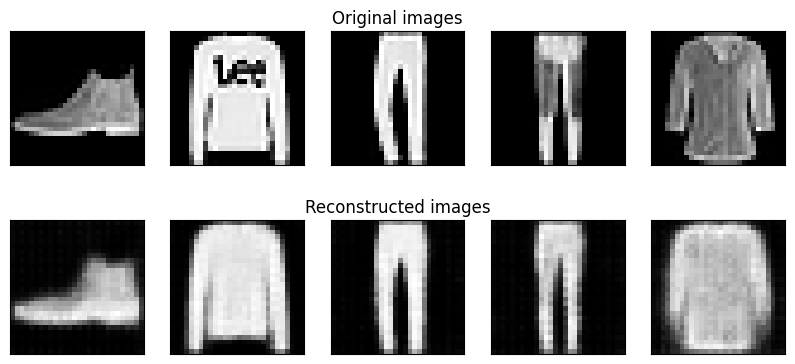

	 partial train loss (single batch): 0.021077
	 partial train loss (single batch): 0.020813
	 partial train loss (single batch): 0.019440
	 partial train loss (single batch): 0.019203
	 partial train loss (single batch): 0.020616
	 partial train loss (single batch): 0.020417
	 partial train loss (single batch): 0.019944
	 partial train loss (single batch): 0.021703
	 partial train loss (single batch): 0.020349
	 partial train loss (single batch): 0.020993
	 partial train loss (single batch): 0.020830
	 partial train loss (single batch): 0.019343
	 partial train loss (single batch): 0.019010
	 partial train loss (single batch): 0.019491
	 partial train loss (single batch): 0.019940
	 partial train loss (single batch): 0.020174
	 partial train loss (single batch): 0.019158
	 partial train loss (single batch): 0.020804
	 partial train loss (single batch): 0.020301
	 partial train loss (single batch): 0.020417
	 partial train loss (single batch): 0.018808
	 partial train loss (single batch

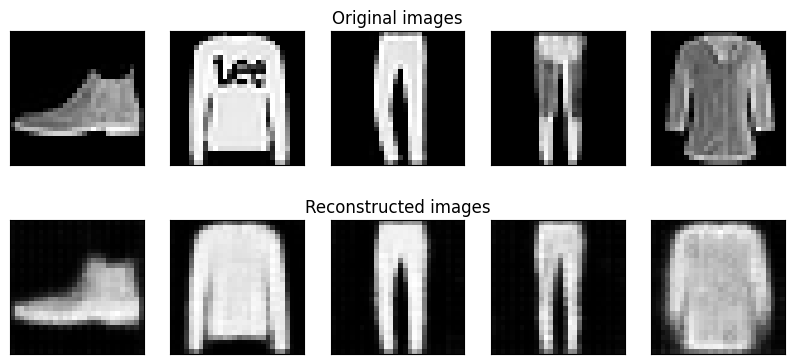

	 partial train loss (single batch): 0.020871
	 partial train loss (single batch): 0.020640
	 partial train loss (single batch): 0.019306
	 partial train loss (single batch): 0.019047
	 partial train loss (single batch): 0.020488
	 partial train loss (single batch): 0.020261
	 partial train loss (single batch): 0.019735
	 partial train loss (single batch): 0.021551
	 partial train loss (single batch): 0.020171
	 partial train loss (single batch): 0.020844
	 partial train loss (single batch): 0.020665
	 partial train loss (single batch): 0.019183
	 partial train loss (single batch): 0.018905
	 partial train loss (single batch): 0.019319
	 partial train loss (single batch): 0.019812
	 partial train loss (single batch): 0.019990
	 partial train loss (single batch): 0.019000
	 partial train loss (single batch): 0.020634
	 partial train loss (single batch): 0.020142
	 partial train loss (single batch): 0.020255
	 partial train loss (single batch): 0.018646
	 partial train loss (single batch

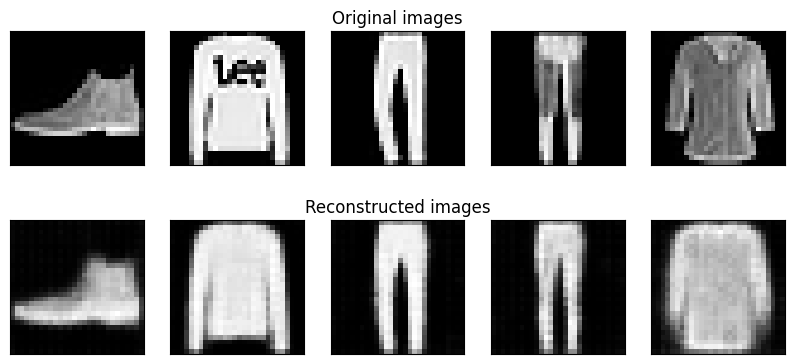

	 partial train loss (single batch): 0.020698
	 partial train loss (single batch): 0.020486
	 partial train loss (single batch): 0.019160
	 partial train loss (single batch): 0.018903
	 partial train loss (single batch): 0.020372
	 partial train loss (single batch): 0.020134
	 partial train loss (single batch): 0.019591
	 partial train loss (single batch): 0.021376
	 partial train loss (single batch): 0.020031
	 partial train loss (single batch): 0.020724
	 partial train loss (single batch): 0.020517
	 partial train loss (single batch): 0.019050
	 partial train loss (single batch): 0.018772
	 partial train loss (single batch): 0.019187
	 partial train loss (single batch): 0.019714
	 partial train loss (single batch): 0.019855
	 partial train loss (single batch): 0.018873
	 partial train loss (single batch): 0.020479
	 partial train loss (single batch): 0.020024
	 partial train loss (single batch): 0.020107
	 partial train loss (single batch): 0.018506
	 partial train loss (single batch

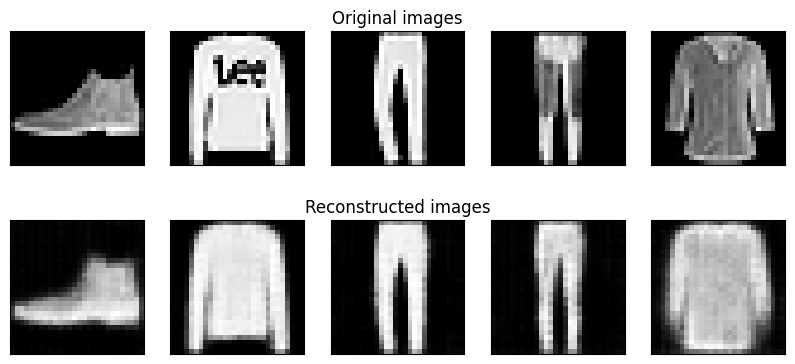

	 partial train loss (single batch): 0.020577
	 partial train loss (single batch): 0.020372
	 partial train loss (single batch): 0.019015
	 partial train loss (single batch): 0.018816
	 partial train loss (single batch): 0.020279
	 partial train loss (single batch): 0.020002
	 partial train loss (single batch): 0.019485
	 partial train loss (single batch): 0.021259
	 partial train loss (single batch): 0.019914
	 partial train loss (single batch): 0.020597
	 partial train loss (single batch): 0.020417
	 partial train loss (single batch): 0.018914
	 partial train loss (single batch): 0.018619
	 partial train loss (single batch): 0.019075
	 partial train loss (single batch): 0.019603
	 partial train loss (single batch): 0.019722
	 partial train loss (single batch): 0.018743
	 partial train loss (single batch): 0.020321
	 partial train loss (single batch): 0.019897
	 partial train loss (single batch): 0.019946
	 partial train loss (single batch): 0.018358
	 partial train loss (single batch

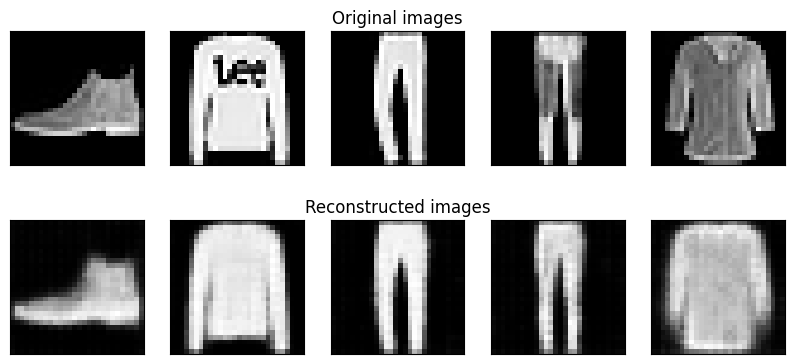

	 partial train loss (single batch): 0.020461
	 partial train loss (single batch): 0.020277
	 partial train loss (single batch): 0.018941
	 partial train loss (single batch): 0.018747
	 partial train loss (single batch): 0.020170
	 partial train loss (single batch): 0.019873
	 partial train loss (single batch): 0.019371
	 partial train loss (single batch): 0.021156
	 partial train loss (single batch): 0.019788
	 partial train loss (single batch): 0.020494
	 partial train loss (single batch): 0.020303
	 partial train loss (single batch): 0.018813
	 partial train loss (single batch): 0.018505
	 partial train loss (single batch): 0.018932
	 partial train loss (single batch): 0.019534
	 partial train loss (single batch): 0.019608
	 partial train loss (single batch): 0.018626
	 partial train loss (single batch): 0.020193
	 partial train loss (single batch): 0.019816
	 partial train loss (single batch): 0.019832
	 partial train loss (single batch): 0.018248
	 partial train loss (single batch

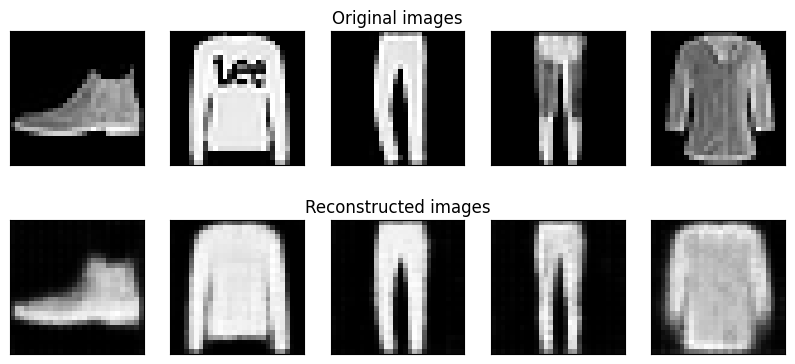

	 partial train loss (single batch): 0.020369
	 partial train loss (single batch): 0.020164
	 partial train loss (single batch): 0.018836
	 partial train loss (single batch): 0.018650
	 partial train loss (single batch): 0.020069
	 partial train loss (single batch): 0.019808
	 partial train loss (single batch): 0.019269
	 partial train loss (single batch): 0.021080
	 partial train loss (single batch): 0.019712
	 partial train loss (single batch): 0.020370
	 partial train loss (single batch): 0.020235
	 partial train loss (single batch): 0.018713
	 partial train loss (single batch): 0.018435
	 partial train loss (single batch): 0.018866
	 partial train loss (single batch): 0.019467
	 partial train loss (single batch): 0.019530
	 partial train loss (single batch): 0.018551
	 partial train loss (single batch): 0.020075
	 partial train loss (single batch): 0.019728
	 partial train loss (single batch): 0.019750
	 partial train loss (single batch): 0.018140
	 partial train loss (single batch

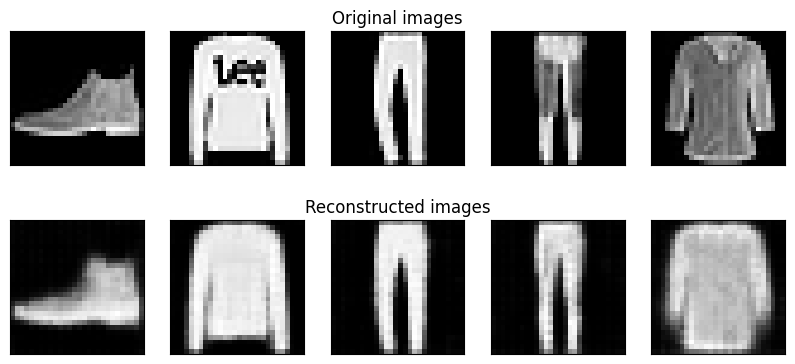

	 partial train loss (single batch): 0.020266
	 partial train loss (single batch): 0.020095
	 partial train loss (single batch): 0.018755
	 partial train loss (single batch): 0.018607
	 partial train loss (single batch): 0.020026
	 partial train loss (single batch): 0.019728
	 partial train loss (single batch): 0.019178
	 partial train loss (single batch): 0.021007
	 partial train loss (single batch): 0.019615
	 partial train loss (single batch): 0.020290
	 partial train loss (single batch): 0.020154
	 partial train loss (single batch): 0.018627
	 partial train loss (single batch): 0.018373
	 partial train loss (single batch): 0.018776
	 partial train loss (single batch): 0.019402
	 partial train loss (single batch): 0.019440
	 partial train loss (single batch): 0.018479
	 partial train loss (single batch): 0.019985
	 partial train loss (single batch): 0.019644
	 partial train loss (single batch): 0.019669
	 partial train loss (single batch): 0.018029
	 partial train loss (single batch

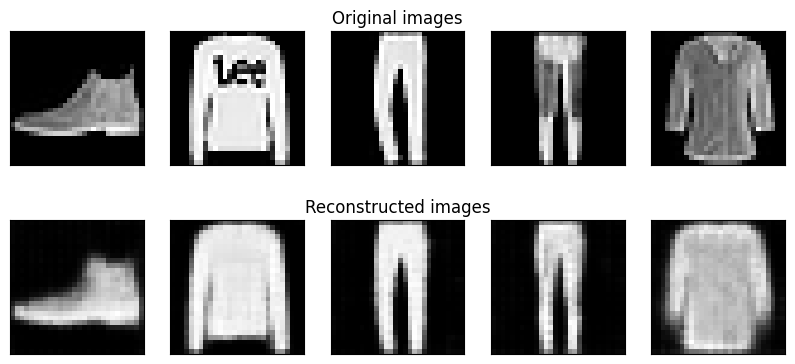

	 partial train loss (single batch): 0.020203
	 partial train loss (single batch): 0.020048
	 partial train loss (single batch): 0.018692
	 partial train loss (single batch): 0.018554
	 partial train loss (single batch): 0.019981
	 partial train loss (single batch): 0.019686
	 partial train loss (single batch): 0.019095
	 partial train loss (single batch): 0.020946
	 partial train loss (single batch): 0.019548
	 partial train loss (single batch): 0.020272
	 partial train loss (single batch): 0.020105
	 partial train loss (single batch): 0.018578
	 partial train loss (single batch): 0.018307
	 partial train loss (single batch): 0.018702
	 partial train loss (single batch): 0.019402
	 partial train loss (single batch): 0.019364
	 partial train loss (single batch): 0.018405
	 partial train loss (single batch): 0.019885
	 partial train loss (single batch): 0.019568
	 partial train loss (single batch): 0.019627
	 partial train loss (single batch): 0.017960
	 partial train loss (single batch

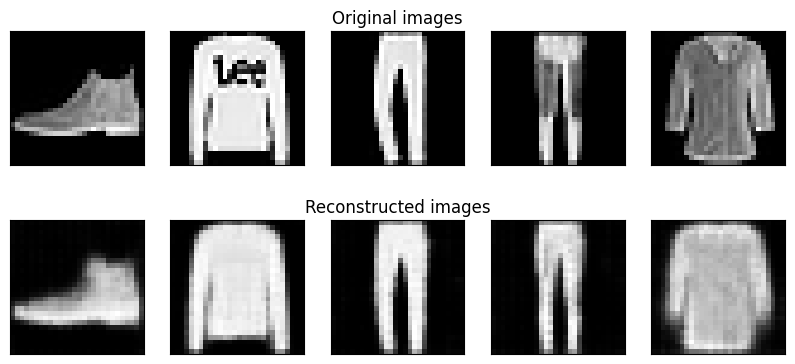

	 partial train loss (single batch): 0.020113
	 partial train loss (single batch): 0.019999
	 partial train loss (single batch): 0.018615
	 partial train loss (single batch): 0.018508
	 partial train loss (single batch): 0.019937
	 partial train loss (single batch): 0.019596
	 partial train loss (single batch): 0.019030
	 partial train loss (single batch): 0.020865
	 partial train loss (single batch): 0.019515
	 partial train loss (single batch): 0.020198
	 partial train loss (single batch): 0.020031
	 partial train loss (single batch): 0.018502
	 partial train loss (single batch): 0.018249
	 partial train loss (single batch): 0.018609
	 partial train loss (single batch): 0.019326
	 partial train loss (single batch): 0.019296
	 partial train loss (single batch): 0.018334
	 partial train loss (single batch): 0.019796
	 partial train loss (single batch): 0.019476
	 partial train loss (single batch): 0.019551
	 partial train loss (single batch): 0.017869
	 partial train loss (single batch

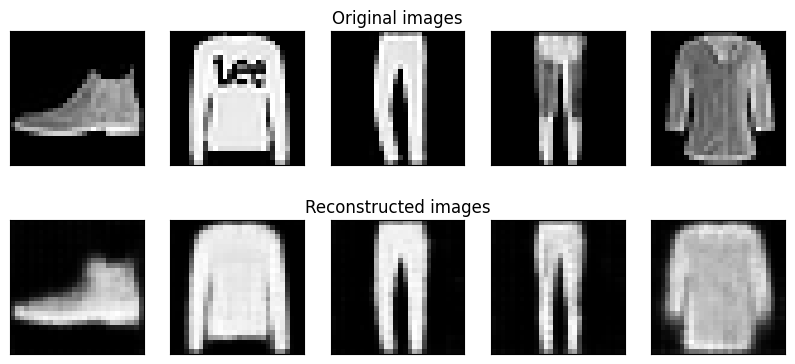

	 partial train loss (single batch): 0.020037
	 partial train loss (single batch): 0.019969
	 partial train loss (single batch): 0.018565
	 partial train loss (single batch): 0.018399
	 partial train loss (single batch): 0.019926
	 partial train loss (single batch): 0.019527
	 partial train loss (single batch): 0.018965
	 partial train loss (single batch): 0.020839
	 partial train loss (single batch): 0.019397
	 partial train loss (single batch): 0.020188
	 partial train loss (single batch): 0.019968
	 partial train loss (single batch): 0.018422
	 partial train loss (single batch): 0.018266
	 partial train loss (single batch): 0.018544
	 partial train loss (single batch): 0.019304
	 partial train loss (single batch): 0.019243
	 partial train loss (single batch): 0.018264
	 partial train loss (single batch): 0.019784
	 partial train loss (single batch): 0.019385
	 partial train loss (single batch): 0.019558
	 partial train loss (single batch): 0.017810
	 partial train loss (single batch

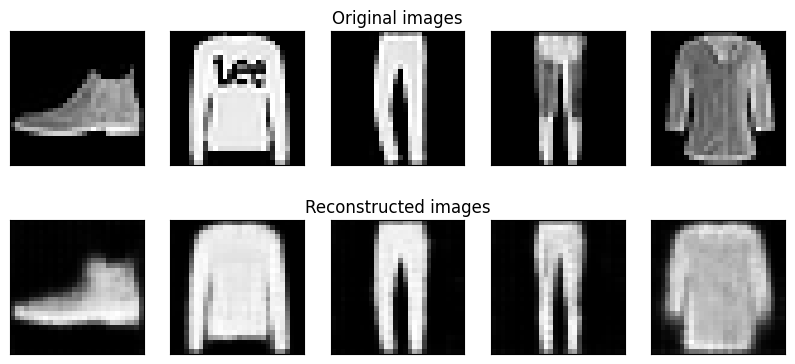

	 partial train loss (single batch): 0.019987
	 partial train loss (single batch): 0.019879
	 partial train loss (single batch): 0.018520
	 partial train loss (single batch): 0.018290
	 partial train loss (single batch): 0.019887
	 partial train loss (single batch): 0.019506
	 partial train loss (single batch): 0.018873
	 partial train loss (single batch): 0.020848
	 partial train loss (single batch): 0.019314
	 partial train loss (single batch): 0.020099
	 partial train loss (single batch): 0.019957
	 partial train loss (single batch): 0.018373
	 partial train loss (single batch): 0.018240
	 partial train loss (single batch): 0.018524
	 partial train loss (single batch): 0.019200
	 partial train loss (single batch): 0.019228
	 partial train loss (single batch): 0.018167
	 partial train loss (single batch): 0.019698
	 partial train loss (single batch): 0.019326
	 partial train loss (single batch): 0.019413
	 partial train loss (single batch): 0.017783
	 partial train loss (single batch

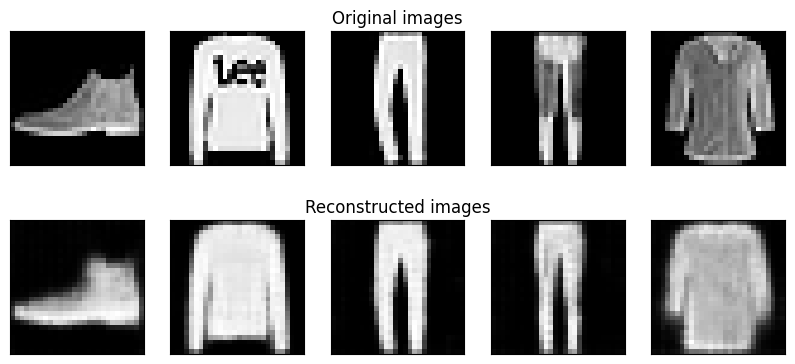

	 partial train loss (single batch): 0.019908
	 partial train loss (single batch): 0.019800
	 partial train loss (single batch): 0.018479
	 partial train loss (single batch): 0.018270
	 partial train loss (single batch): 0.019812
	 partial train loss (single batch): 0.019480
	 partial train loss (single batch): 0.018806
	 partial train loss (single batch): 0.020750
	 partial train loss (single batch): 0.019274
	 partial train loss (single batch): 0.020040
	 partial train loss (single batch): 0.019881
	 partial train loss (single batch): 0.018319
	 partial train loss (single batch): 0.018140
	 partial train loss (single batch): 0.018472
	 partial train loss (single batch): 0.019147
	 partial train loss (single batch): 0.019177
	 partial train loss (single batch): 0.018111
	 partial train loss (single batch): 0.019646
	 partial train loss (single batch): 0.019277
	 partial train loss (single batch): 0.019325
	 partial train loss (single batch): 0.017728
	 partial train loss (single batch

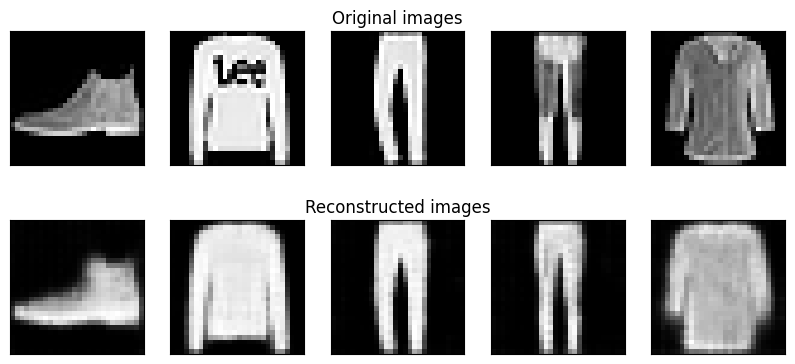

	 partial train loss (single batch): 0.019865
	 partial train loss (single batch): 0.019747
	 partial train loss (single batch): 0.018412
	 partial train loss (single batch): 0.018237
	 partial train loss (single batch): 0.019759
	 partial train loss (single batch): 0.019454
	 partial train loss (single batch): 0.018736
	 partial train loss (single batch): 0.020702
	 partial train loss (single batch): 0.019240
	 partial train loss (single batch): 0.019959
	 partial train loss (single batch): 0.019831
	 partial train loss (single batch): 0.018319
	 partial train loss (single batch): 0.018116
	 partial train loss (single batch): 0.018394
	 partial train loss (single batch): 0.019117
	 partial train loss (single batch): 0.019123
	 partial train loss (single batch): 0.018068
	 partial train loss (single batch): 0.019600
	 partial train loss (single batch): 0.019207
	 partial train loss (single batch): 0.019258
	 partial train loss (single batch): 0.017673
	 partial train loss (single batch

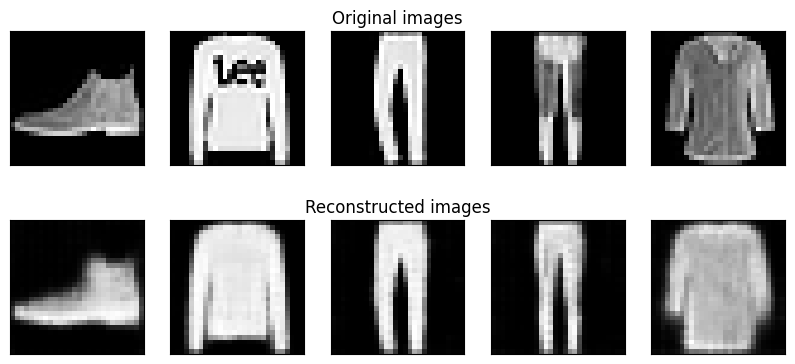

	 partial train loss (single batch): 0.019831
	 partial train loss (single batch): 0.019708
	 partial train loss (single batch): 0.018384
	 partial train loss (single batch): 0.018233
	 partial train loss (single batch): 0.019732
	 partial train loss (single batch): 0.019412
	 partial train loss (single batch): 0.018702
	 partial train loss (single batch): 0.020675
	 partial train loss (single batch): 0.019208
	 partial train loss (single batch): 0.019942
	 partial train loss (single batch): 0.019801
	 partial train loss (single batch): 0.018300
	 partial train loss (single batch): 0.018067
	 partial train loss (single batch): 0.018357
	 partial train loss (single batch): 0.019074
	 partial train loss (single batch): 0.019069
	 partial train loss (single batch): 0.018033
	 partial train loss (single batch): 0.019546
	 partial train loss (single batch): 0.019163
	 partial train loss (single batch): 0.019202
	 partial train loss (single batch): 0.017625
	 partial train loss (single batch

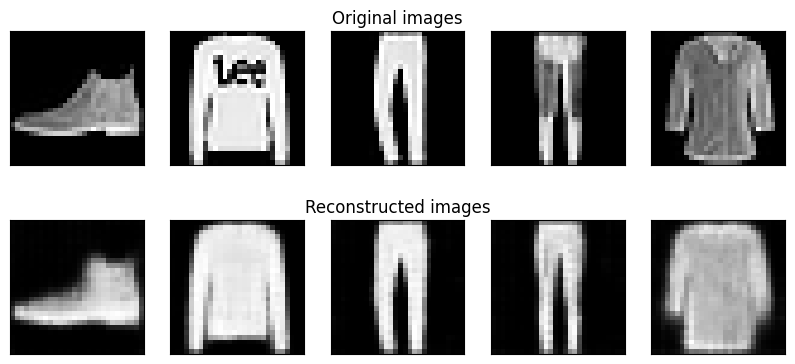

	 partial train loss (single batch): 0.019816
	 partial train loss (single batch): 0.019651
	 partial train loss (single batch): 0.018333
	 partial train loss (single batch): 0.018220
	 partial train loss (single batch): 0.019675
	 partial train loss (single batch): 0.019359
	 partial train loss (single batch): 0.018647
	 partial train loss (single batch): 0.020639
	 partial train loss (single batch): 0.019195
	 partial train loss (single batch): 0.019871
	 partial train loss (single batch): 0.019715
	 partial train loss (single batch): 0.018308
	 partial train loss (single batch): 0.017998
	 partial train loss (single batch): 0.018290
	 partial train loss (single batch): 0.019108
	 partial train loss (single batch): 0.018983
	 partial train loss (single batch): 0.018013
	 partial train loss (single batch): 0.019504
	 partial train loss (single batch): 0.019130
	 partial train loss (single batch): 0.019201
	 partial train loss (single batch): 0.017568
	 partial train loss (single batch

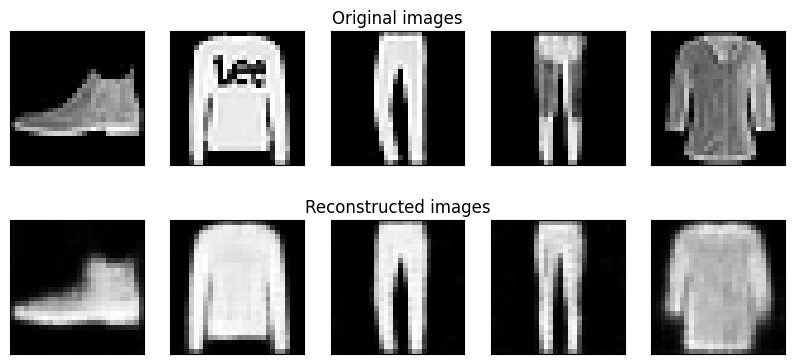

	 partial train loss (single batch): 0.019783
	 partial train loss (single batch): 0.019608
	 partial train loss (single batch): 0.018298
	 partial train loss (single batch): 0.018181
	 partial train loss (single batch): 0.019628
	 partial train loss (single batch): 0.019295
	 partial train loss (single batch): 0.018587
	 partial train loss (single batch): 0.020596
	 partial train loss (single batch): 0.019123
	 partial train loss (single batch): 0.019816
	 partial train loss (single batch): 0.019685
	 partial train loss (single batch): 0.018192
	 partial train loss (single batch): 0.017931
	 partial train loss (single batch): 0.018244
	 partial train loss (single batch): 0.019041
	 partial train loss (single batch): 0.018929
	 partial train loss (single batch): 0.017941
	 partial train loss (single batch): 0.019458
	 partial train loss (single batch): 0.019055
	 partial train loss (single batch): 0.019151
	 partial train loss (single batch): 0.017521
	 partial train loss (single batch

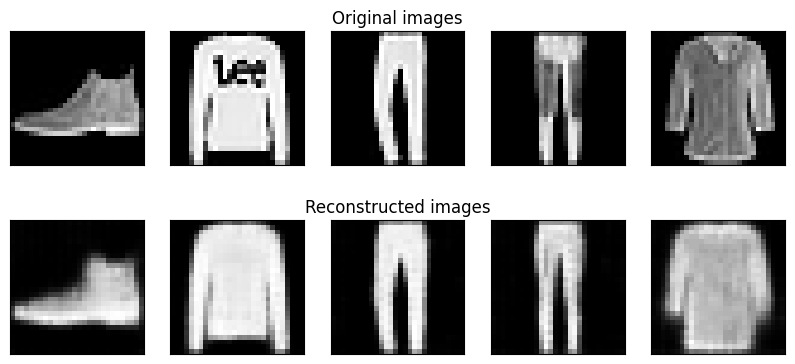

	 partial train loss (single batch): 0.019725
	 partial train loss (single batch): 0.019573
	 partial train loss (single batch): 0.018259
	 partial train loss (single batch): 0.018159
	 partial train loss (single batch): 0.019570
	 partial train loss (single batch): 0.019252
	 partial train loss (single batch): 0.018560
	 partial train loss (single batch): 0.020560
	 partial train loss (single batch): 0.019083
	 partial train loss (single batch): 0.019814
	 partial train loss (single batch): 0.019650
	 partial train loss (single batch): 0.018166
	 partial train loss (single batch): 0.017895
	 partial train loss (single batch): 0.018168
	 partial train loss (single batch): 0.019001
	 partial train loss (single batch): 0.018879
	 partial train loss (single batch): 0.017905
	 partial train loss (single batch): 0.019396
	 partial train loss (single batch): 0.019038
	 partial train loss (single batch): 0.019132
	 partial train loss (single batch): 0.017487
	 partial train loss (single batch

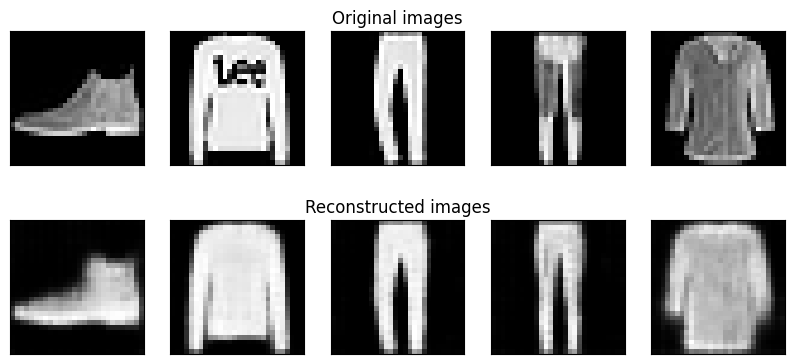

	 partial train loss (single batch): 0.019667
	 partial train loss (single batch): 0.019523
	 partial train loss (single batch): 0.018231
	 partial train loss (single batch): 0.018147
	 partial train loss (single batch): 0.019557
	 partial train loss (single batch): 0.019223
	 partial train loss (single batch): 0.018506
	 partial train loss (single batch): 0.020518
	 partial train loss (single batch): 0.019031
	 partial train loss (single batch): 0.019764
	 partial train loss (single batch): 0.019637
	 partial train loss (single batch): 0.018136
	 partial train loss (single batch): 0.017881
	 partial train loss (single batch): 0.018151
	 partial train loss (single batch): 0.018939
	 partial train loss (single batch): 0.018848
	 partial train loss (single batch): 0.017864
	 partial train loss (single batch): 0.019380
	 partial train loss (single batch): 0.018966
	 partial train loss (single batch): 0.019060
	 partial train loss (single batch): 0.017462
	 partial train loss (single batch

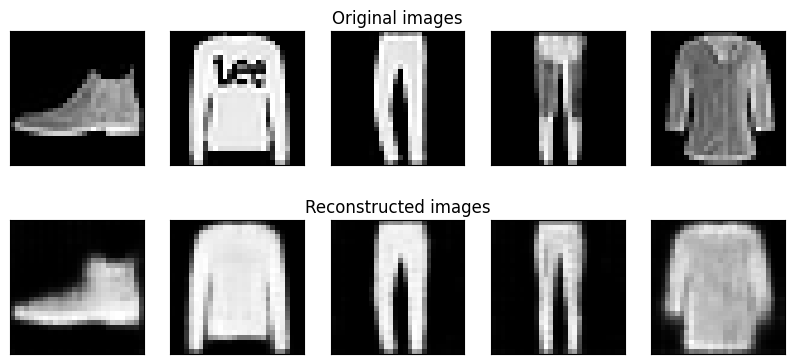

	 partial train loss (single batch): 0.019667
	 partial train loss (single batch): 0.019493
	 partial train loss (single batch): 0.018206
	 partial train loss (single batch): 0.018105
	 partial train loss (single batch): 0.019520
	 partial train loss (single batch): 0.019178
	 partial train loss (single batch): 0.018464
	 partial train loss (single batch): 0.020481
	 partial train loss (single batch): 0.018997
	 partial train loss (single batch): 0.019710
	 partial train loss (single batch): 0.019603
	 partial train loss (single batch): 0.018115
	 partial train loss (single batch): 0.017840
	 partial train loss (single batch): 0.018090
	 partial train loss (single batch): 0.018900
	 partial train loss (single batch): 0.018816
	 partial train loss (single batch): 0.017844
	 partial train loss (single batch): 0.019324
	 partial train loss (single batch): 0.018933
	 partial train loss (single batch): 0.019030
	 partial train loss (single batch): 0.017421
	 partial train loss (single batch

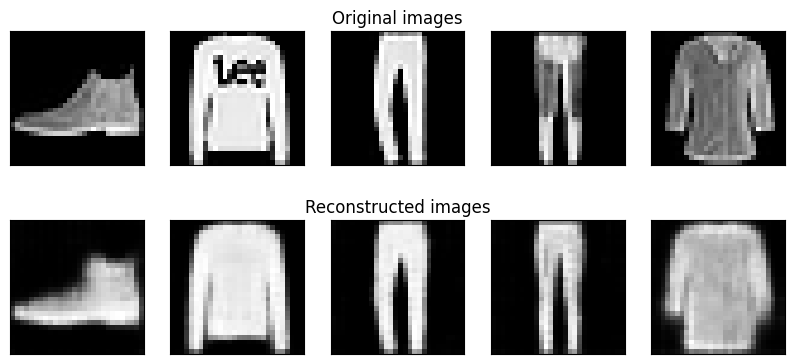

	 partial train loss (single batch): 0.019676
	 partial train loss (single batch): 0.019471
	 partial train loss (single batch): 0.018166
	 partial train loss (single batch): 0.018066
	 partial train loss (single batch): 0.019504
	 partial train loss (single batch): 0.019132
	 partial train loss (single batch): 0.018443
	 partial train loss (single batch): 0.020447
	 partial train loss (single batch): 0.018953
	 partial train loss (single batch): 0.019684
	 partial train loss (single batch): 0.019593
	 partial train loss (single batch): 0.018079
	 partial train loss (single batch): 0.017816
	 partial train loss (single batch): 0.018060
	 partial train loss (single batch): 0.018847
	 partial train loss (single batch): 0.018834
	 partial train loss (single batch): 0.017808
	 partial train loss (single batch): 0.019314
	 partial train loss (single batch): 0.018909
	 partial train loss (single batch): 0.019022
	 partial train loss (single batch): 0.017388
	 partial train loss (single batch

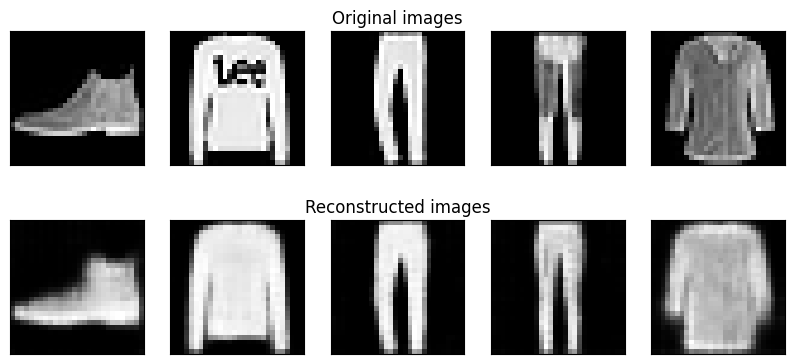

In [17]:
num_epochs = 30
history={'train_loss':[],'val_loss':[]}

for epoch in range(num_epochs):
    train_loss = train_epoch(encoder,decoder,device,train_loader,loss_fn,optim)
    val_loss = test_epoch(encoder,decoder,device,valid_loader,loss_fn)
    
    print('\n EPOCH {}/{} \t train loss {:.3f} \t val loss {:.3f}'.format(epoch + 1, num_epochs,train_loss,val_loss))
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    plot_ae_outputs(encoder,decoder,n=5)

In [17]:
test_epoch(encoder,decoder,device,test_loader,loss_fn).item()

0.019240006804466248

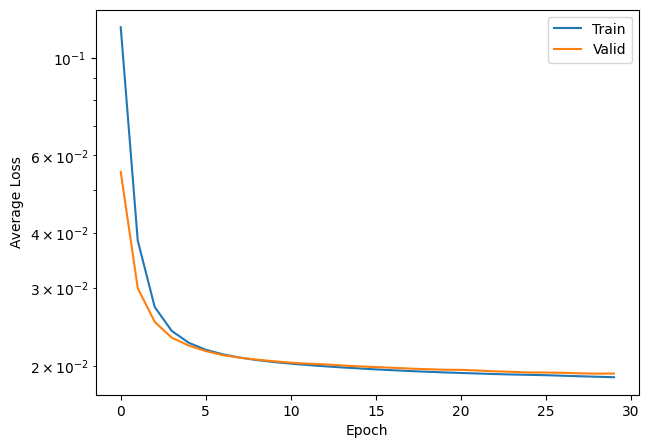

In [18]:
# Train and validation loss

plt.figure(figsize=(7,5))
plt.semilogy(history['train_loss'], label='Train')
plt.semilogy(history['val_loss'], label='Valid')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
#plt.grid()
plt.legend()
#plt.title('loss')
plt.show()

tensor([-0.3652, -0.0589,  0.8125,  0.1935])
tensor([0.5865, 0.7306, 0.8967, 0.4532])


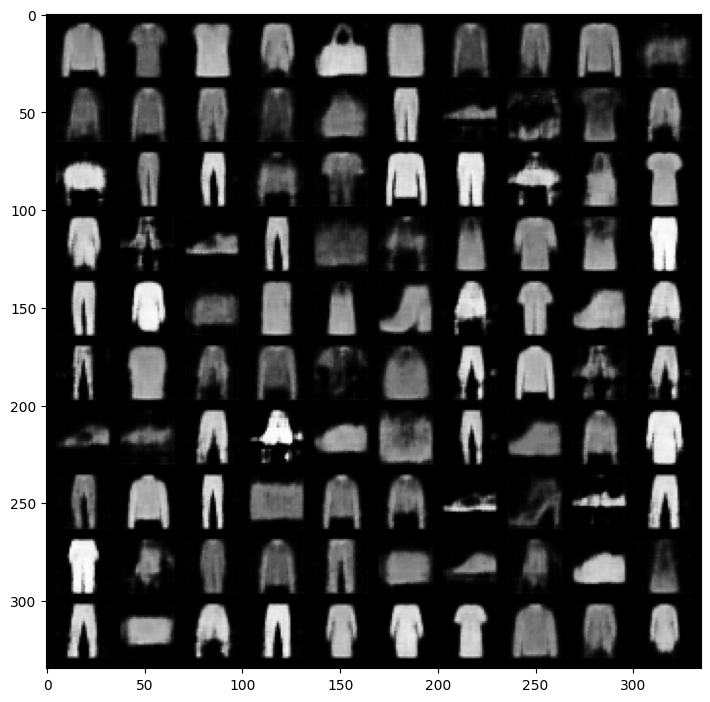

In [19]:
def show_image(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

def show_top_n(encoder, decoder, dataset, n=10):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        # calculate mean and std of latent code, generated takining in test images as inputs 
        images, labels = map(list, zip(*[dataset[i] for i in range(10)]))
        images = torch.stack(images).to(device)
        latent = encoder(images)
        latent = latent.cpu()

        mean = latent.mean(dim=0)
        print(mean)
        std = (latent - mean).pow(2).mean(dim=0).sqrt()
        print(std)

        # sample latent vectors from the normal distribution
        latent = torch.randn(128, dim)*std + mean

        # reconstruct images from the random latent vectors
        latent = latent.to(device)
        img_recon = decoder(latent)
        img_recon = img_recon.cpu()

        fig, ax = plt.subplots(figsize=(20, 8.5))
        show_image(torchvision.utils.make_grid(img_recon[:100],10,5))
        plt.show()
        
show_top_n(encoder, decoder, test_dataset, n=10)